In [1]:
print("Notebook Working!")

Notebook Working!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.io import imread
from skimage.color import rgb2gray

In [3]:
mask_raw = imread("../data/976970_mask.png")

print("Shape:", mask_raw.shape)
print("Unique values:", np.unique(mask_raw))

Shape: (1024, 1024, 3)
Unique values: [  0 255]


In [4]:
gray = rgb2gray(mask_raw)
binary = gray > 0.5

print("Road pixels:", binary.sum())

Road pixels: 141409


In [5]:
skeleton = skeletonize(binary)

print("Skeleton pixels:", skeleton.sum())
print("How much thinner:", round(binary.sum() / skeleton.sum(), 1), "x")

Skeleton pixels: 11268
How much thinner: 12.5 x


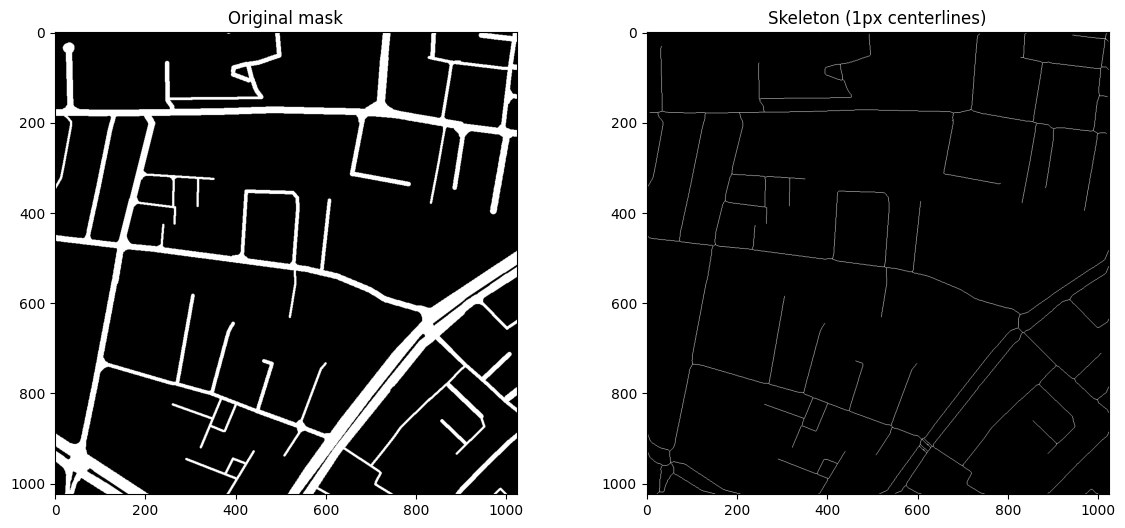

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(binary, cmap='gray')
axes[0].set_title("Original mask")

axes[1].imshow(skeleton, cmap='gray')
axes[1].set_title("Skeleton (1px centerlines)")

plt.savefig("../outputs/skeleton_result.png")
plt.show()

In [7]:
from pathlib import Path

mask_dir = Path("../data/")
mask_files = list(mask_dir.glob("*_mask.png"))[:5]

for mf in mask_files:
    raw = imread(str(mf))
    gray = rgb2gray(raw) if raw.ndim == 3 else raw / 255.0
    binary = gray > 0.5
    skel = skeletonize(binary)
    ratio = round(binary.sum() / max(skel.sum(), 1), 1)
    print(f"{mf.name:35s}  road px: {binary.sum():7d}  skel px: {skel.sum():6d}  ratio: {ratio}x")

9663_mask.png                        road px:   56826  skel px:   4397  ratio: 12.9x
966525_mask.png                      road px:   86155  skel px:   5204  ratio: 16.6x
969845_mask.png                      road px:   54193  skel px:   3790  ratio: 14.3x
97272_mask.png                       road px:  125952  skel px:   8082  ratio: 15.6x
976970_mask.png                      road px:  141409  skel px:  11268  ratio: 12.5x


In [2]:
import sys
sys.path.append("../src")

from graph.skeleton import mask_to_graph
from skimage.io import imread
from skimage.color import rgb2gray
import numpy as np

mask_raw = imread("../data/966525_mask.png")   # your file name here
gray = rgb2gray(mask_raw) if mask_raw.ndim == 3 else mask_raw / 255.0
mask = (gray > 0.5).astype(np.uint8) * 255

result = mask_to_graph(mask)
print("Nodes:", len(result["nodes"]))
print("Edges:", len(result["edges"]))

Nodes: 41
Edges: 36


In [3]:
# First node
first_node_id = list(result["nodes"].keys())[0]
print("Node:", first_node_id, "→", result["nodes"][first_node_id])

# First edge
e = result["edges"][0]
print("Edge:", e["from"], "→", e["to"])
print("Length:", round(e["length_px"], 2), "pixels")
print("Path points:", len(e["pixel_path"]))

Node: 0 → {'pixel_coord': (0, 503)}
Edge: 0 → 2
Length: 68.63 pixels
Path points: 63


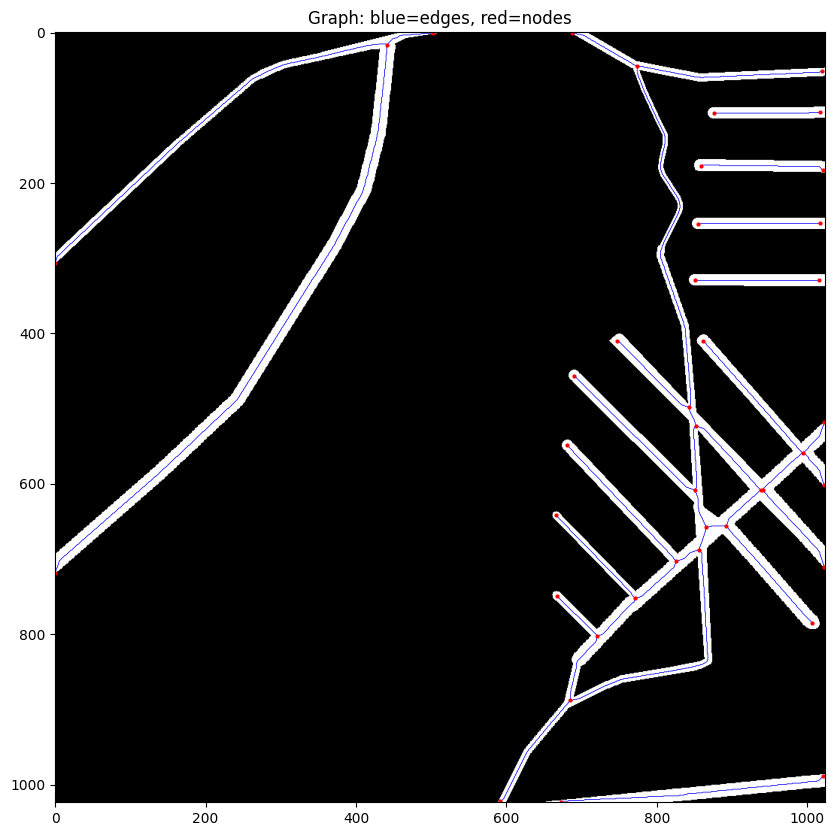

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mask, cmap='gray')

# Draw edges
for edge in result["edges"]:
    pts = edge["pixel_path"]
    xs = [p[1] for p in pts]
    ys = [p[0] for p in pts]
    ax.plot(xs, ys, 'b-', linewidth=0.5)

# Draw nodes
for nid, ndata in result["nodes"].items():
    r, c = ndata["pixel_coord"]
    ax.plot(c, r, 'r.', markersize=4)

ax.set_title("Graph: blue=edges, red=nodes")
plt.savefig("../outputs/graph_result.png")
plt.show()